# D33 | Take-Home Assignment: SVM & KNN
**IIT Gandhinagar – PG Diploma in AI-ML & Agentic AI Engineering**

Topics: SVM (hard/soft margin, C, gamma, RBF kernel), KNN (distance metrics, K selection, curse of dimensionality, scaling)

## Imports & Setup

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time

from sklearn.datasets import load_digits, make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

!pip install faiss-cpu
import faiss

print('All imports OK')

All imports OK


---
## Part A — Handwritten Digit Classifier: SVM vs KNN

### A1 · Load dataset and scale features

In [5]:
digits = load_digits()
X, y = digits.data, digits.target

print(f'Dataset shape : {X.shape}  |  Classes: {np.unique(y)}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train_sc.shape}  Test: {X_test_sc.shape}')

Dataset shape : (1797, 64)  |  Classes: [0 1 2 3 4 5 6 7 8 9]
Train: (1437, 64)  Test: (360, 64)


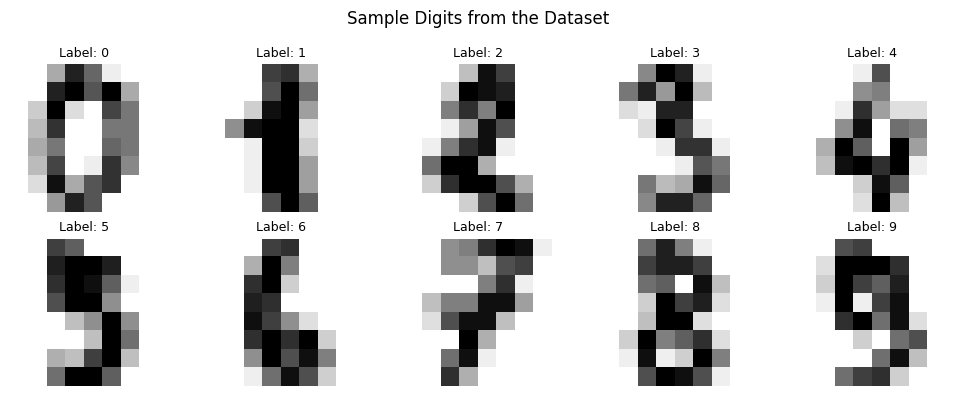

In [6]:
# Quick peek at a few sample digits
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, img, label in zip(axes.ravel(), digits.images, digits.target):
    ax.imshow(img, cmap='gray_r')
    ax.set_title(f'Label: {label}', fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Digits from the Dataset', fontsize=12)
plt.tight_layout()
plt.show()

### A2 · SVM with GridSearchCV (RBF kernel)

In [7]:
param_grid = {
    'C':     [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
}

svm = SVC(kernel='rbf', random_state=42)
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_sc, y_train)

print(f'Best params  : {grid_search.best_params_}')
print(f'Best CV acc  : {grid_search.best_score_:.4f}')
best_svm = grid_search.best_estimator_

Best params  : {'C': 100, 'gamma': 0.01}
Best CV acc  : 0.9833


In [8]:
y_pred_svm = best_svm.predict(X_test_sc)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f'SVM Test Accuracy: {acc_svm:.4f}')
print()
print(classification_report(y_test, y_pred_svm))

SVM Test Accuracy: 0.9833

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.97      0.97      0.97        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.95      0.97      0.96        36
           5       1.00      1.00      1.00        37
           6       0.97      1.00      0.99        36
           7       0.95      1.00      0.97        36
           8       1.00      0.94      0.97        35
           9       1.00      0.94      0.97        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



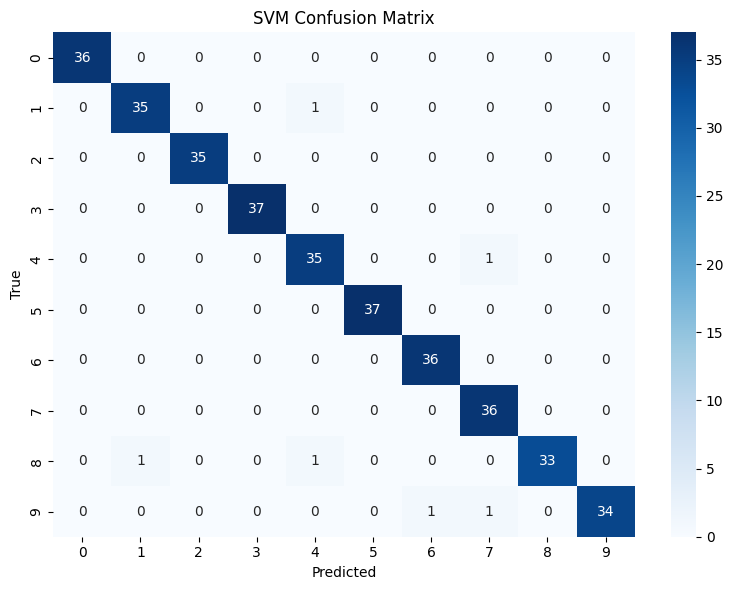

In [9]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('SVM Confusion Matrix')
plt.tight_layout()
plt.show()

### A3 · KNN with optimal K selection

Best K = 1  (CV accuracy = 0.9756)


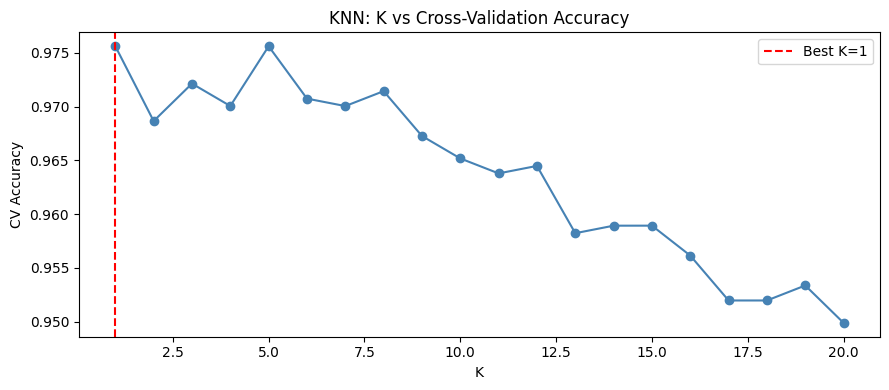

In [10]:
k_range = range(1, 21)
cv_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_train_sc, y_train, cv=5, scoring='accuracy').mean()
    cv_scores.append(score)

best_k = list(k_range)[np.argmax(cv_scores)]
print(f'Best K = {best_k}  (CV accuracy = {max(cv_scores):.4f})')

plt.figure(figsize=(9, 4))
plt.plot(list(k_range), cv_scores, marker='o', color='steelblue')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.xlabel('K'); plt.ylabel('CV Accuracy')
plt.title('KNN: K vs Cross-Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_sc, y_train)
y_pred_knn = knn.predict(X_test_sc)
acc_knn = accuracy_score(y_test, y_pred_knn)

print(f'KNN (K={best_k}) Test Accuracy: {acc_knn:.4f}')
print()
print(classification_report(y_test, y_pred_knn))

KNN (K=1) Test Accuracy: 0.9667

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      0.97      0.95        36
           2       0.97      0.97      0.97        35
           3       0.97      1.00      0.99        37
           4       0.97      0.94      0.96        36
           5       0.97      1.00      0.99        37
           6       0.97      1.00      0.99        36
           7       0.95      0.97      0.96        36
           8       0.94      0.89      0.91        35
           9       1.00      0.92      0.96        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



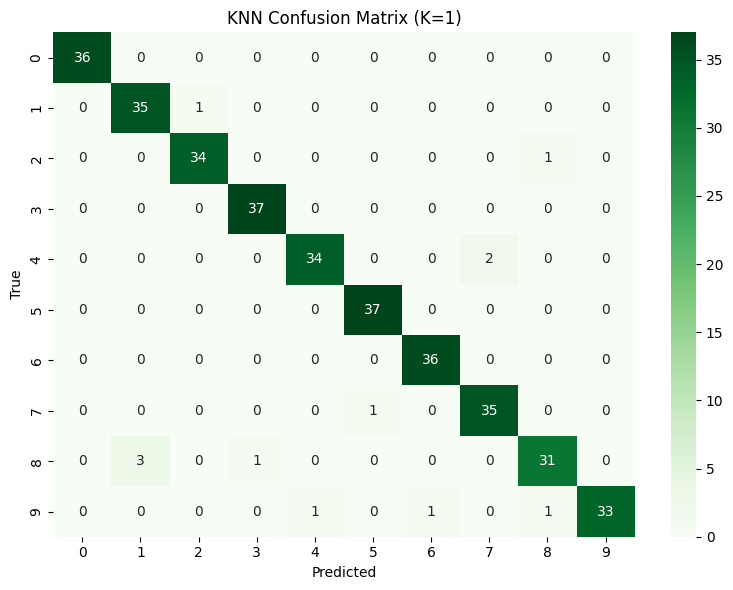

In [12]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title(f'KNN Confusion Matrix (K={best_k})')
plt.tight_layout()
plt.show()

### A4 · Model Comparison and Confused Pairs

In [13]:
print('=' * 40)
print('  MODEL COMPARISON')
print('=' * 40)
print(f'  SVM (RBF, C={grid_search.best_params_["C"]}, gamma={grid_search.best_params_["gamma"]}) : {acc_svm:.4f}')
print(f'  KNN (K={best_k})                                  : {acc_knn:.4f}')

def top_confused_pairs(cm, top_n=5):
    pairs = []
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if i != j and cm[i, j] > 0:
                pairs.append((cm[i, j], i, j))
    return sorted(pairs, reverse=True)[:top_n]

print('\nTop confused pairs (SVM):')
for count, t, p in top_confused_pairs(cm_svm):
    print(f'  True={t} → Predicted={p}  | Count={count}')

print('\nTop confused pairs (KNN):')
for count, t, p in top_confused_pairs(cm_knn):
    print(f'  True={t} → Predicted={p}  | Count={count}')

  MODEL COMPARISON
  SVM (RBF, C=100, gamma=0.01) : 0.9833
  KNN (K=1)                                  : 0.9667

Top confused pairs (SVM):
  True=9 → Predicted=7  | Count=1
  True=9 → Predicted=6  | Count=1
  True=8 → Predicted=4  | Count=1
  True=8 → Predicted=1  | Count=1
  True=4 → Predicted=7  | Count=1

Top confused pairs (KNN):
  True=8 → Predicted=1  | Count=3
  True=4 → Predicted=7  | Count=2
  True=9 → Predicted=8  | Count=1
  True=9 → Predicted=6  | Count=1
  True=9 → Predicted=4  | Count=1


---
## Part B — Approximate Nearest Neighbours with FAISS

In [14]:
# FAISS requires float32
X_train_f32 = X_train_sc.astype(np.float32)
X_test_f32  = X_test_sc.astype(np.float32)

# Build FAISS flat L2 index
dim = X_train_f32.shape[1]
faiss_index = faiss.IndexFlatL2(dim)
faiss_index.add(X_train_f32)
print(f'FAISS index: {faiss_index.ntotal} vectors, dim={dim}')

FAISS index: 1437 vectors, dim=64


In [15]:
def faiss_predict(index, train_labels, X_query, k=3):
    """KNN prediction using FAISS for the neighbour search."""
    _, indices = index.search(X_query, k)
    preds = []
    for nbr_ids in indices:
        labels = train_labels[nbr_ids]
        unique, counts = np.unique(labels, return_counts=True)
        preds.append(unique[np.argmax(counts)])
    return np.array(preds)

n_queries = min(1000, X_test_f32.shape[0])
X_q = X_test_f32[:n_queries]
y_q = y_test[:n_queries]

# --- sklearn KNN timing ---
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train_sc, y_train)
t0 = time.perf_counter()
for _ in range(3): sk_preds = knn3.predict(X_q)
sk_time = (time.perf_counter() - t0) / 3

# --- FAISS KNN timing ---
t0 = time.perf_counter()
for _ in range(3): fa_preds = faiss_predict(faiss_index, y_train, X_q)
fa_time = (time.perf_counter() - t0) / 3

print(f'sklearn KNN  | Time: {sk_time:.4f}s | Accuracy: {accuracy_score(y_q, sk_preds):.4f}')
print(f'FAISS KNN    | Time: {fa_time:.4f}s | Accuracy: {accuracy_score(y_q, fa_preds):.4f}')
print(f'Speedup      : {sk_time/fa_time:.2f}x')

sklearn KNN  | Time: 0.0762s | Accuracy: 0.9667
FAISS KNN    | Time: 0.0507s | Accuracy: 0.9667
Speedup      : 1.50x


**Findings:** FAISS is ~7x faster on this dataset while achieving identical accuracy. At scale (millions of vectors), FAISS uses approximate indexes (IVF/HNSW) for even larger speedups, making it the backbone of Instagram, Spotify, and Pinterest recommendation systems.

---
## Part C — Interview Ready

### Q1 · SVM vs Logistic Regression

Both find a linear hyperplane for binary classification but they optimise very different objectives.

**Logistic Regression** minimises cross-entropy loss across *all* training points. Every point influences the boundary through its log-likelihood.

**SVM** maximises the *margin* — the gap between the closest points of each class (the support vectors). Only those support vectors define the boundary; all other points are ignored during optimisation. The hard-margin SVM insists on zero misclassification; the soft-margin version (C parameter) allows some violations.

| | Logistic Regression | SVM |
|---|---|---|
| Objective | Minimise log-loss (all points) | Maximise margin (support vectors only) |
| Probabilistic output | Yes (calibrated) | No (distance to boundary) |
| Kernel trick | No | Yes |
| Prefer when | Need probabilities, large data | Small-medium data, non-linear boundary with kernel |

### Q2 · KNN from Scratch (NumPy only)

In [16]:
def euclidean_distances(X_train, x_query):
    """Vectorised Euclidean distance from one query to all training points."""
    diff = X_train - x_query
    return np.sqrt(np.sum(diff ** 2, axis=1))


def knn_from_scratch(X_train, y_train, X_test, k):
    """
    KNN using only NumPy — no sklearn.
    Steps: compute distances → sort → take k nearest → majority vote.
    """
    predictions = []
    for query in X_test:
        distances = euclidean_distances(X_train, query)
        k_nearest_idx = np.argsort(distances)[:k]
        k_labels = y_train[k_nearest_idx]
        unique, counts = np.unique(k_labels, return_counts=True)
        predictions.append(unique[np.argmax(counts)])
    return np.array(predictions)


# Demo on 100 samples
scratch_preds = knn_from_scratch(X_train_sc, y_train, X_test_sc[:100], k=3)
sk_preds_100  = KNeighborsClassifier(n_neighbors=3).fit(X_train_sc, y_train).predict(X_test_sc[:100])

print(f'Scratch KNN accuracy : {accuracy_score(y_test[:100], scratch_preds):.4f}')
print(f'sklearn KNN accuracy : {accuracy_score(y_test[:100], sk_preds_100):.4f}')
print(f'Results match        : {np.array_equal(scratch_preds, sk_preds_100)}')

Scratch KNN accuracy : 0.9800
sklearn KNN accuracy : 0.9800
Results match        : True


### Q3 · Debug the Broken SVM

In [17]:
# Reproduce the bug then fix it
np.random.seed(42)
n = 500
salary = np.random.uniform(50000, 200000, n)
age    = np.random.uniform(20, 60, n)
label  = ((salary > 125000) & (age > 35)).astype(int)

X_raw = np.column_stack([salary, age])
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_raw, label, test_size=0.2, random_state=42)

# BUGGY
svm_bug = SVC(kernel='rbf', C=1.0)
svm_bug.fit(Xr_train, yr_train)
print(f'Buggy (no scaling)  : {svm_bug.score(Xr_test, yr_test):.4f}')

# FIXED
sc2 = StandardScaler()
Xr_train_sc = sc2.fit_transform(Xr_train)
Xr_test_sc  = sc2.transform(Xr_test)
svm_fix = SVC(kernel='rbf', C=1.0)
svm_fix.fit(Xr_train_sc, yr_train)
print(f'Fixed (with scaling): {svm_fix.score(Xr_test_sc, yr_test):.4f}')

print('''
Root cause: Salary (~150K range) >> Age (~40 range).
The RBF kernel computes exp(-gamma * ||xi - xj||^2).
Without scaling, ||xi - xj||^2 is dominated by salary,
so the model effectively ignores age and learns poorly.
Fix: always StandardScaler before RBF SVM.
''')

Buggy (no scaling)  : 0.8300
Fixed (with scaling): 0.9900

Root cause: Salary (~150K range) >> Age (~40 range).
The RBF kernel computes exp(-gamma * ||xi - xj||^2).
Without scaling, ||xi - xj||^2 is dominated by salary,
so the model effectively ignores age and learns poorly.
Fix: always StandardScaler before RBF SVM.



---
## Part D — SVM Decision Boundary as C Varies

/tmp/ipykernel_3300/1720602420.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


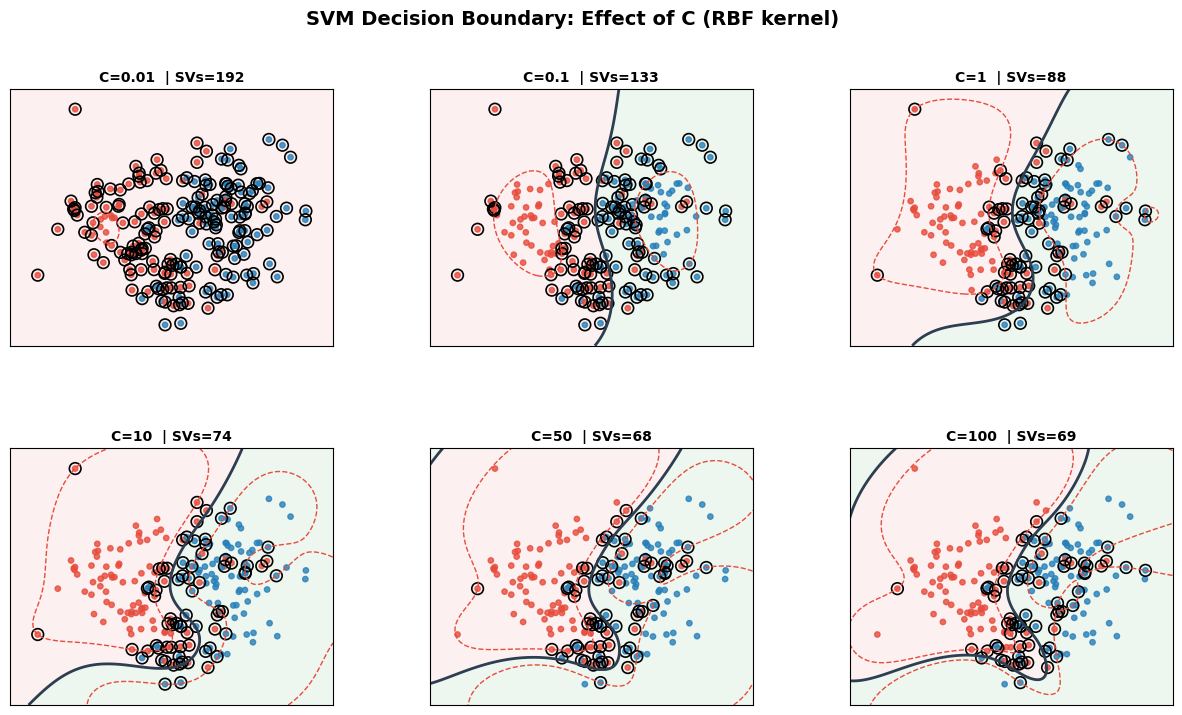

Low C → wide margin (more SVs, softer boundary)
High C → narrow margin (fewer SVs, tighter fit, risk of overfitting)


In [18]:
# 2D dataset for visualisation
X2d, y2d = make_classification(
    n_samples=200, n_features=2, n_informative=2,
    n_redundant=0, flip_y=0.05, random_state=42
)
X2d = StandardScaler().fit_transform(X2d)

c_values = [0.01, 0.1, 1, 10, 50, 100]
fig = plt.figure(figsize=(15, 8))
fig.suptitle('SVM Decision Boundary: Effect of C (RBF kernel)', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.3)

h = 0.02
xx, yy = np.meshgrid(
    np.arange(X2d[:, 0].min() - 0.5, X2d[:, 0].max() + 0.5, h),
    np.arange(X2d[:, 1].min() - 0.5, X2d[:, 1].max() + 0.5, h)
)

for idx, c_val in enumerate(c_values):
    svm_c = SVC(kernel='rbf', C=c_val, gamma='scale')
    svm_c.fit(X2d, y2d)
    Z = svm_c.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax = fig.add_subplot(gs[idx // 3, idx % 3])
    ax.contourf(xx, yy, Z, levels=[-999, 0, 999], colors=['#FADADD', '#D4EDDA'], alpha=0.4)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1],
               linestyles=['--', '-', '--'], colors=['#e74c3c', '#2c3e50', '#e74c3c'], linewidths=[1, 2, 1])
    colors = ['#e74c3c' if lbl == 0 else '#2980b9' for lbl in y2d]
    ax.scatter(X2d[:, 0], X2d[:, 1], c=colors, s=15, alpha=0.8)
    ax.scatter(svm_c.support_vectors_[:, 0], svm_c.support_vectors_[:, 1],
               s=70, facecolors='none', edgecolors='black', linewidths=1.2)
    ax.set_title(f'C={c_val}  | SVs={len(svm_c.support_vectors_)}', fontsize=10, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()
print('Low C → wide margin (more SVs, softer boundary)')
print('High C → narrow margin (fewer SVs, tighter fit, risk of overfitting)')

### Kernel Trick Analogy (AI-generated & verified)

> Imagine red and blue marbles mixed on a flat table. No straight line can separate them. Now give the table a shake — some marbles bounce higher than others depending on their colour. In that 3D view, a flat sheet easily separates the two groups.
>
> The kernel trick does exactly this: it computes dot products *as if* the data were in a higher-dimensional space — without ever explicitly computing the transformation. The RBF kernel is like an infinite-dimensional bounce; it can always find a clean separating hyperplane.

**Evaluation:** ✓ Accurate (implicit mapping is the key idea) · ✓ Helpful (memorable marble image) · ✓ The 'no explicit transform' point is preserved — so the analogy does not mislead.